In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.decomposition import PCA

In [4]:
# load data
save_params_path = Path('fitted_parameters')
monkey_id = 1
n_bins = 12

pkl_file = Path(save_params_path) / f"value_manifold_monkey{monkey_id}_{n_bins}bins_params.pkl"
with open(pkl_file, 'rb') as file:
    elbo = pickle.load(file)

In [23]:
# compute PC-reduced perceptual locations
pca_fit = PCA(n_components=2)

pca_fit.fit(elbo.x.detach())
pc_fit = pca_fit.components_

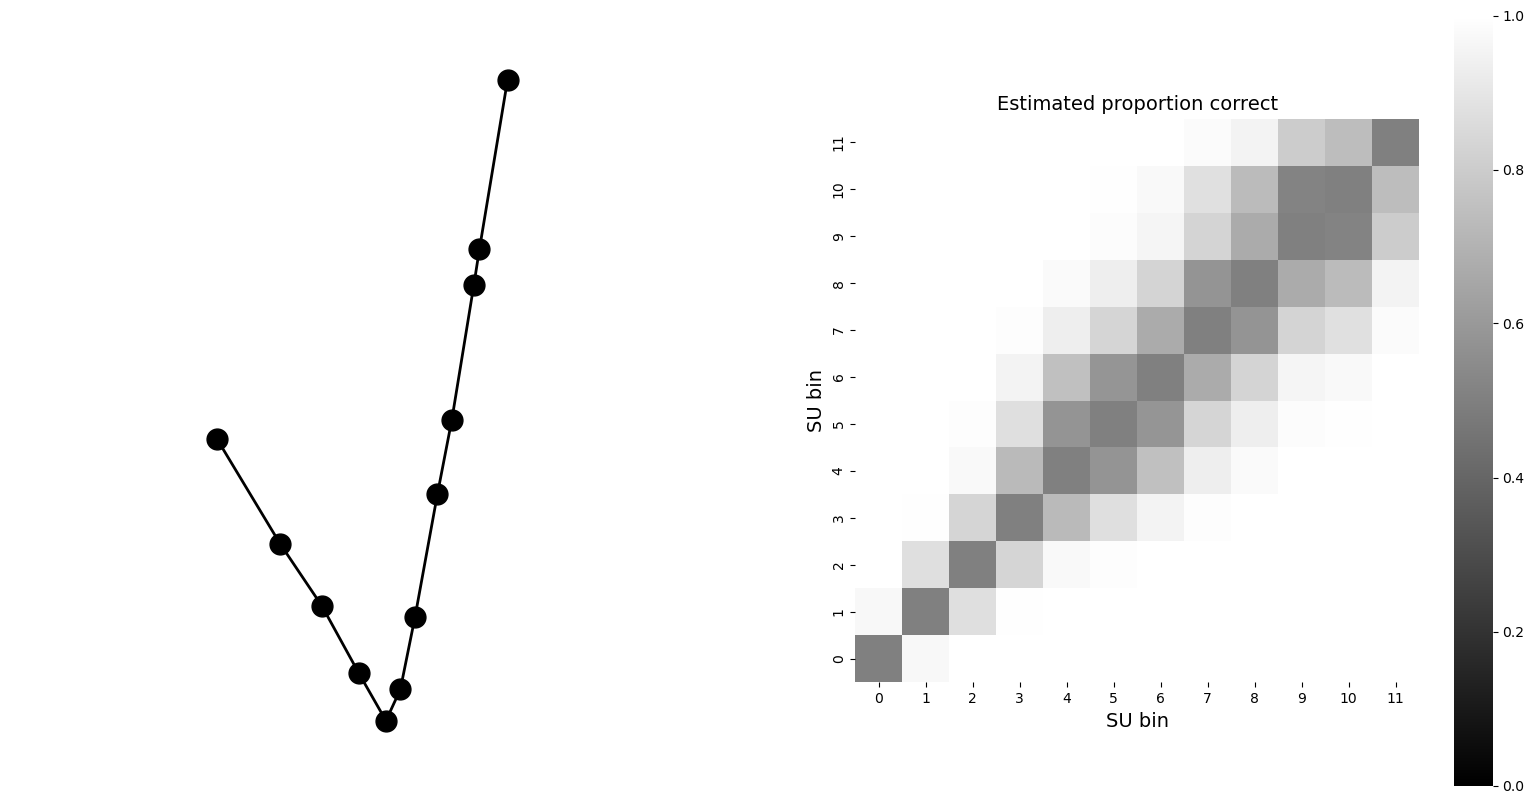

In [45]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10))
axs[0].plot(pc_fit[0, :], pc_fit[1, :], '-ko', markersize=15, linewidth=2)
axs[0].set_xlabel('PC 1')
axs[0].set_ylabel('PC 2')
axs[0].set_box_aspect(1)  
axs[0].set_aspect('equal') 
axs[0].set_axis_off()

sns.heatmap(elbo.p.detach().numpy().squeeze(), ax=axs[1], cmap='gray', vmin=0, vmax=1)
axs[1].invert_yaxis()
axs[1].set_title('Estimated proportion correct', fontsize=14)
# axs[1].set_box_aspect(1)  
axs[1].set_aspect('equal') 
axs[1].set_xlabel('SU bin', fontsize=14)
axs[1].set_ylabel('SU bin', fontsize=14)

plt.show()